# Inspect PCD W1, b1 And PCA Vectors

Notebook pour regarder `W1`, `b1` et les vecteurs PCA des données pour un entraînement PCD sauvegardé en HDF5. La cible principale est un BEBM MLP: `W1 = net.0.weight` et `b1 = net.0.bias`.


In [72]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

from rbms.io import load_params
from rbms.utils import get_saved_updates

plt.rcParams["figure.dpi"] = 120
device = "cpu"
dtype = torch.float32

## Configuration

Change `filename` pour pointer vers l'entraînement à inspecter. `update = None` charge le dernier checkpoint sauvegardé.

In [73]:
filename = Path("/Users/aidan/Documents/Research_Internship/Code/rbms/pcd_trains/BEBM_MLP_SiLU_gradH_h500_DMALA100_lr1e-2_100k.h5")
dataset_filename = Path("data/MNIST_train.h5")
update = None

if not filename.exists():
    candidates = sorted(Path(".").glob("**/*.h5"))
    print("Fichier introuvable. Exemples de fichiers .h5 disponibles:")
    for path in candidates[:20]:
        print(" -", path)

In [74]:
saved_updates = get_saved_updates(str(filename))
if update is None:
    update = int(saved_updates[-1])

params = load_params(str(filename), update, device=device, dtype=dtype)

with h5py.File(filename, "r") as f:
    model_type = f["model_type"][()].decode()
    keys = list(f[f"update_{update}"]["params"].keys())

print("file:", filename)
print("model_type:", model_type)
print("update:", update)
print("num_visibles:", params.num_visibles)
print("parameter keys:", keys)

file: /Users/aidan/Documents/Research_Internship/Code/rbms/pcd_trains/BEBM_MLP_SiLU_gradH_h500_DMALA100_lr1e-2_100k.h5
model_type: BEBM
update: 100000
num_visibles: 784
parameter keys: ['net.0.bias', 'net.0.weight', 'net.2.bias', 'net.2.weight', 'visible_field']


## Helpers

In [75]:
def image_shape(num_visibles):
    side = int(np.sqrt(num_visibles))
    if side * side == num_visibles:
        return side, side
    return 1, num_visibles


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def get_w1_b1(params):
    """Return W1 with shape (num_hidden, num_visibles) and b1 with shape (num_hidden,)."""
    energy = getattr(params, "energy", None)
    if energy is not None and hasattr(energy, "net"):
        for layer in energy.net:
            if isinstance(layer, torch.nn.Linear):
                return to_numpy(layer.weight), to_numpy(layer.bias)

    if energy is not None and hasattr(energy, "weight"):
        return to_numpy(energy.weight).T, to_numpy(energy.hbias)

    if hasattr(params, "weight_matrix"):
        return to_numpy(params.weight_matrix).T, to_numpy(params.hbias)

    raise TypeError("Cannot extract W1 and b1 from this model.")


def normalize_images(images, eps=1e-12):
    images = np.asarray(images, dtype=np.float64)
    flat = images.reshape(images.shape[0], -1)
    scale = np.max(np.abs(flat), axis=1).clip(min=eps)
    return (flat / scale[:, None]).reshape(images.shape)


def plot_image_grid(vectors, title, n_cols=8, max_items=64, cmap="coolwarm"):
    vectors = np.asarray(vectors)
    n_items = min(max_items, vectors.shape[0])
    h, w = image_shape(vectors.shape[1])
    n_cols = min(n_cols, n_items)
    n_rows = int(np.ceil(n_items / n_cols))
    images = normalize_images(vectors[:n_items].reshape(n_items, h, w))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.35 * n_cols, 1.35 * n_rows))
    axes = np.asarray(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for i in range(n_items):
        axes[i].imshow(images[i], cmap=cmap, vmin=-1, vmax=1)
        axes[i].set_title(str(i), fontsize=7)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def pca_from_dataset(dataset_filename, max_samples=10000):
    with h5py.File(dataset_filename, "r") as f:
        data = np.asarray(f["samples"][:max_samples], dtype=np.float32)

    centered = data - data.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    eigvals = singular_values**2 / max(centered.shape[0] - 1, 1)
    return eigvals, vt


def project_w1_on_pca(w1, pca_vecs):
    centered = w1 - w1.mean(axis=0, keepdims=True)
    projections = centered @ pca_vecs.T
    mode_power = (projections**2).sum(axis=0)
    return projections, mode_power


def pca_from_array(data):
    data = np.asarray(data, dtype=np.float32)
    centered = data - data.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    eigvals = singular_values**2 / max(centered.shape[0] - 1, 1)
    return eigvals, vt


def sample_model_visibles(params, num_samples=10000, num_chains=512, n_steps_warmup=1000, n_steps_between=20, kernel="dmala", kernel_params=None):
    if kernel_params is None:
        kernel_params = {}

    chains = params.init_chains(num_samples=num_chains)
    chains = params.sample_state(
        chains=chains,
        n_steps=n_steps_warmup,
        kernel=kernel,
        kernel_params=kernel_params,
    )

    samples = []
    while sum(x.shape[0] for x in samples) < num_samples:
        chains = params.sample_state(
            chains=chains,
            n_steps=n_steps_between,
            kernel=kernel,
            kernel_params=kernel_params,
        )
        samples.append(to_numpy(chains["visible"]))

    return np.concatenate(samples, axis=0)[:num_samples]

def pca_from_w1(w1):
    centered = w1 - w1.mean(axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    eigvals = singular_values**2 / max(centered.shape[0] - 1, 1)
    return eigvals, vt


## PCD W1 et b1

`W1` correspond aux poids visibles de la première couche. Pour un BEBM MLP, c'est `energy.net[0].weight`; pour un RBM-like model, ce sont les poids visibles-hidden transposés. `b1` est le biais associé aux unités de cette première couche.

W1 shape: (500, 784)
b1 shape: (500,)
W1 mean/std: 0.7067445516586304 8.12498950958252
b1 mean/std/min/max: -2.3373148441314697 7.122439384460449 -45.04499816894531 20.89512062072754


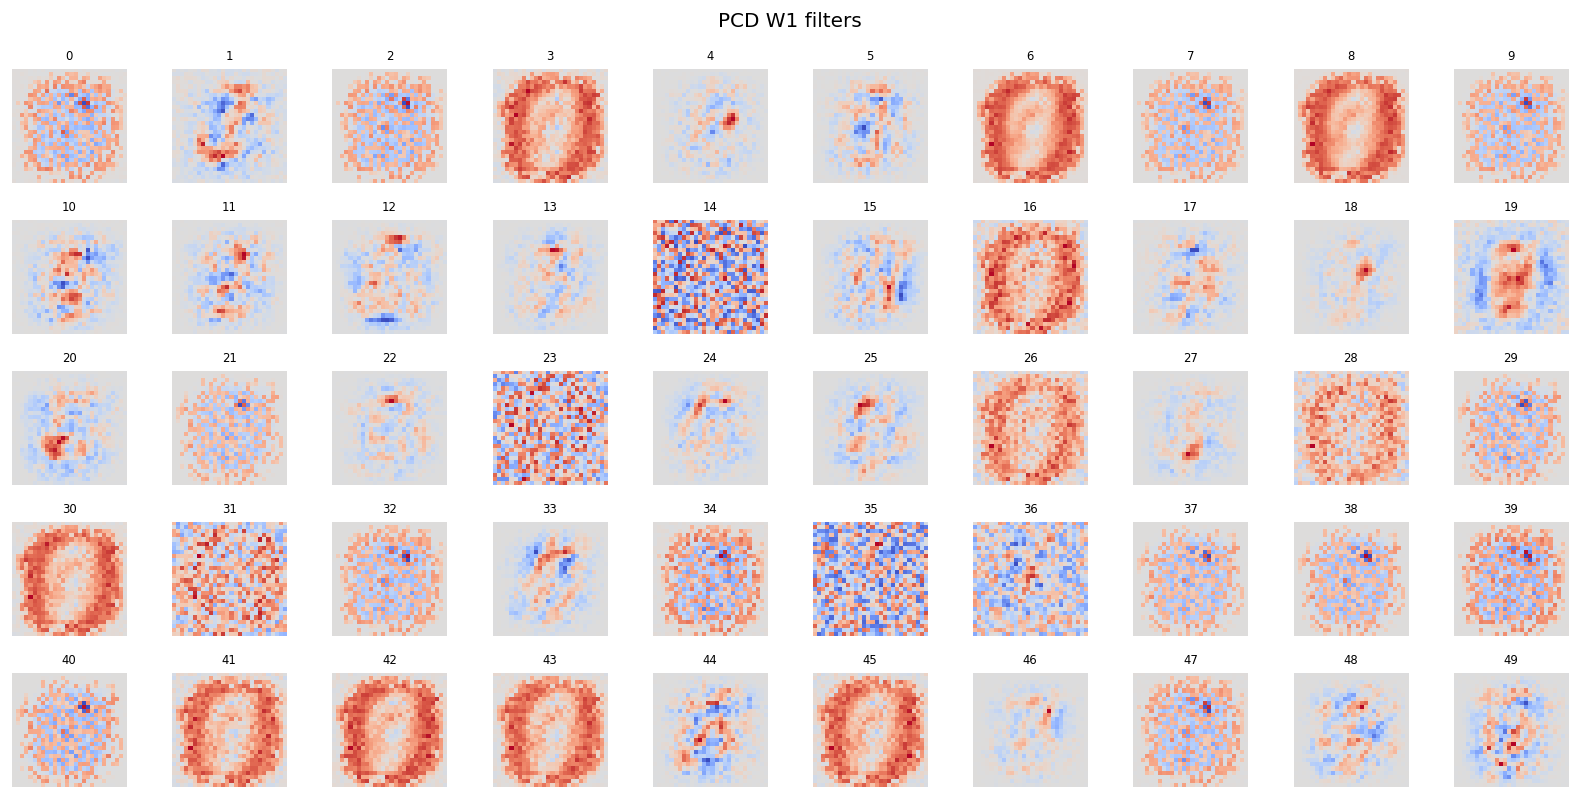

In [76]:
w1, b1 = get_w1_b1(params)
print("W1 shape:", w1.shape)
print("b1 shape:", b1.shape)
print("W1 mean/std:", float(w1.mean()), float(w1.std()))
print("b1 mean/std/min/max:", float(b1.mean()), float(b1.std()), float(b1.min()), float(b1.max()))

plot_image_grid(w1, title="PCD W1 filters", n_cols=10, max_items=50);

## b1

Distribution et valeurs triées de `b1`.

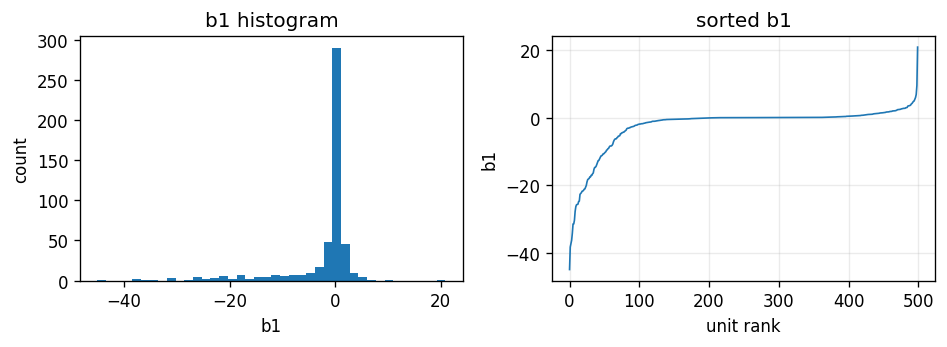

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(b1, bins=40)
axes[0].set_title("b1 histogram")
axes[0].set_xlabel("b1")
axes[0].set_ylabel("count")

axes[1].plot(np.sort(b1), linewidth=1)
axes[1].set_title("sorted b1")
axes[1].set_xlabel("unit rank")
axes[1].set_ylabel("b1")
axes[1].grid(alpha=0.25)
fig.tight_layout()

## PCA sur W1

On traite les lignes de `W1` comme un dataset de filtres. La PCA de `W1` donne les directions visibles principales dans lesquelles les filtres appris varient le plus.


W1 PCA eigenvalues shape: (500,)
W1 PCA vectors shape: (500, 784)


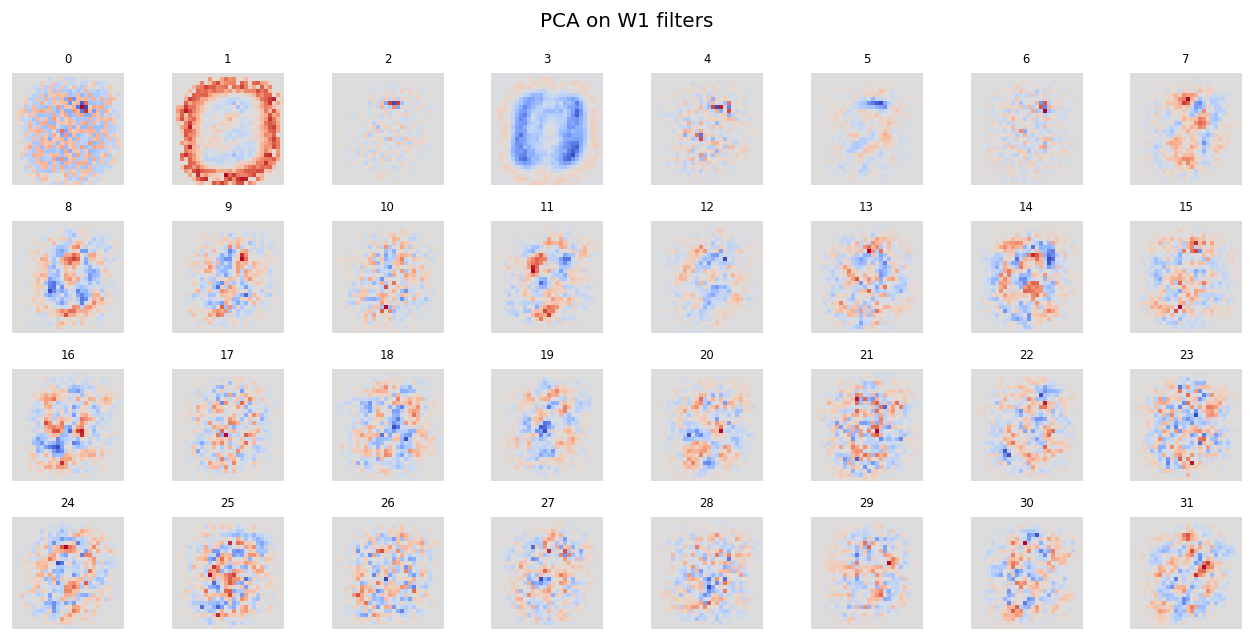

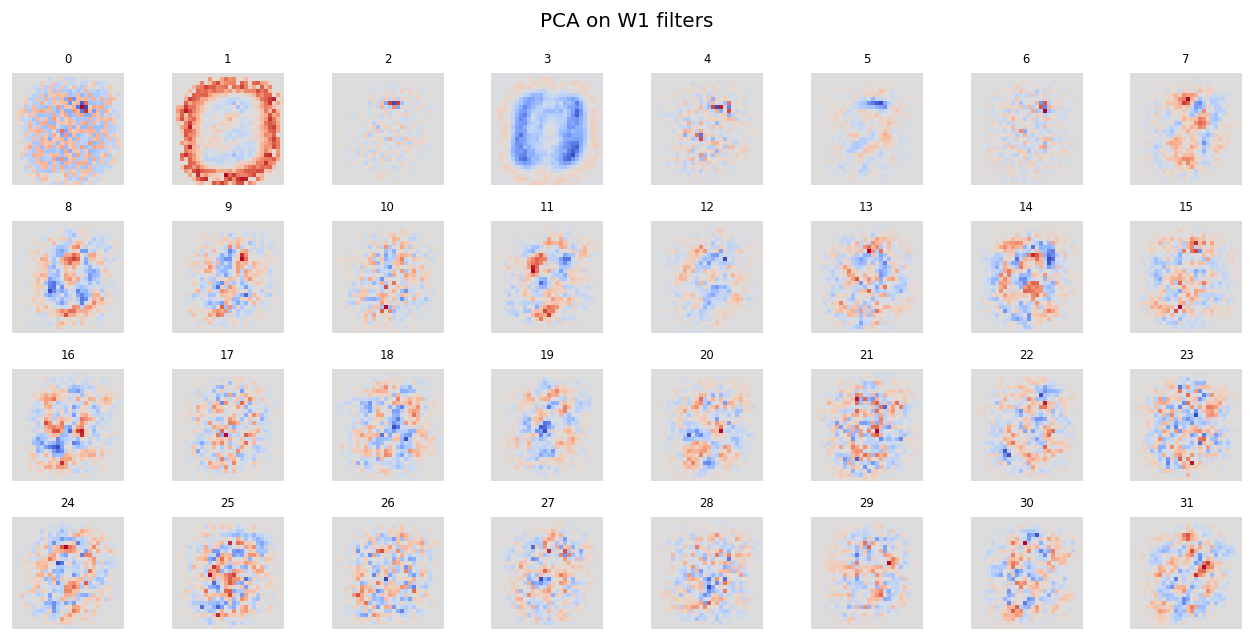

In [78]:
w1_pca_eigvals, w1_pca_vecs = pca_from_w1(w1)
print("W1 PCA eigenvalues shape:", w1_pca_eigvals.shape)
print("W1 PCA vectors shape:", w1_pca_vecs.shape)
plot_image_grid(w1_pca_vecs, title="PCA on W1 filters", n_cols=8, max_items=32)



## Vecteurs PCA des données

On calcule les directions principales des samples du dataset, pas les vecteurs propres de `W1`. Pas de graphe du spectre ici.


PCA vectors shape: (784, 784)
PCA eigenvalues shape: (784,)


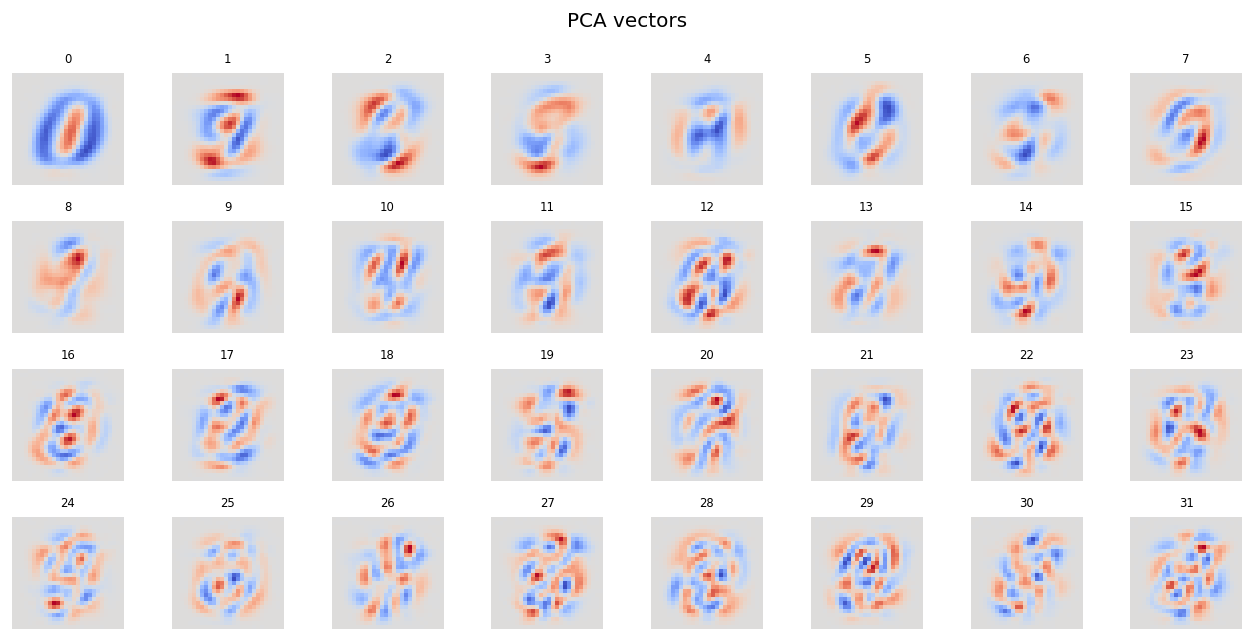

In [81]:
if dataset_filename.exists():
    pca_eigvals, pca_vecs = pca_from_dataset(dataset_filename, max_samples=10000)
    print("PCA vectors shape:", pca_vecs.shape)
    print("PCA eigenvalues shape:", pca_eigvals.shape)
    plot_image_grid(pca_vecs, title="PCA vectors", n_cols=8, max_items=32)
else:
    print("dataset_filename introuvable:", dataset_filename)


chains shape: (2048, 784)
model PCA eigenvalues: [4.1327596  3.571888   2.8020625  2.3510075  1.6508305  1.1151788
 0.47137696 0.3550099  0.3444858  0.3288926 ]
model PCA vectors shape: (784, 784)


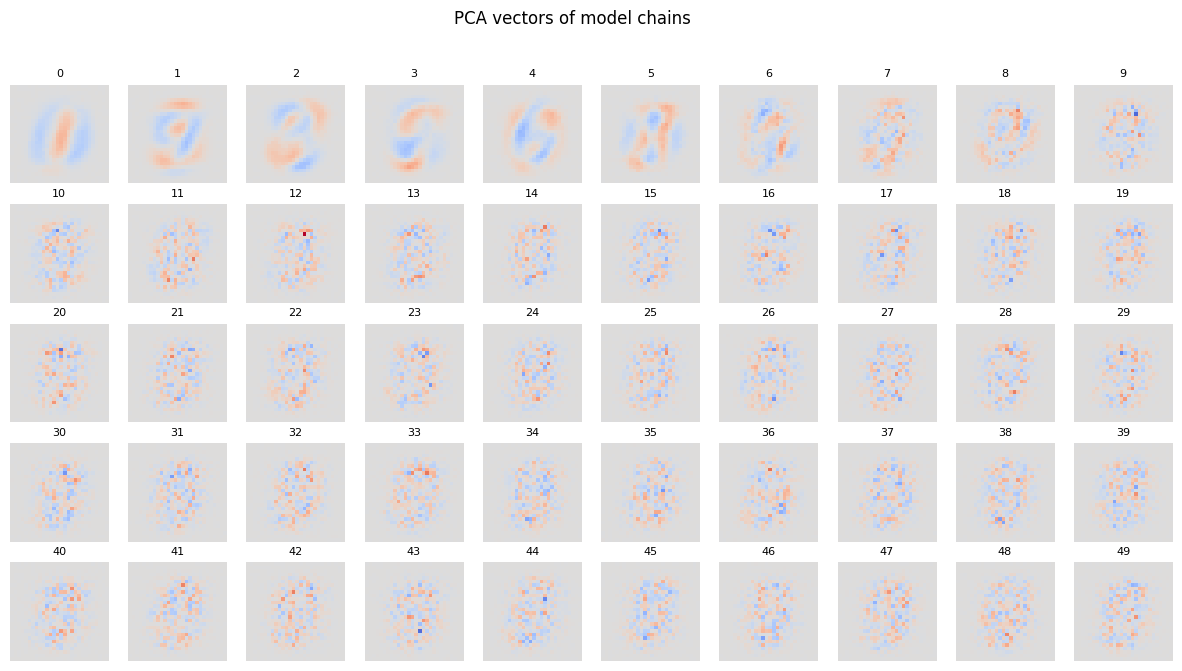

In [2]:
# PCA vectors of the model samples / chains
# Self-contained cell for Inspect_Training_Filters_Eigenvectors.ipynb

from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt

filename = Path("ptt_trains/BEBM_MLP_MNIST_PTT_h1000_ch2048_DMALA300_lr1e-3_100k.h5")
# If needed, replace by your exact file:
# filename = Path("pcd_trains/your_file.h5")

def plot_vectors_grid(vectors, title, n=50, shape=None, cmap="coolwarm"):
    vectors = np.asarray(vectors)

    if shape is None:
        side = int(np.sqrt(vectors.shape[1]))
        shape = (side, side)

    n = min(n, len(vectors))
    n_cols = 10
    n_rows = int(np.ceil(n / n_cols))

    vmax = np.max(np.abs(vectors[:n]))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.5 * n_rows))
    axes = np.asarray(axes).reshape(-1)

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= n:
            continue
        ax.imshow(vectors[i].reshape(shape), cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(str(i), fontsize=8)

    fig.suptitle(title)
    plt.show()


with h5py.File(filename, "r") as f:
    if "parallel_chains" in f:
        chains_visible = np.asarray(f["parallel_chains"])
    elif "chains" in f and "visible" in f["chains"]:
        chains_visible = np.asarray(f["chains"]["visible"])
    else:
        raise KeyError("Could not find final visible chains in the HDF5 file.")

X_model = np.asarray(chains_visible, dtype=np.float32)

model_mean = X_model.mean(axis=0)
X_model_centered = X_model - model_mean

C_model = X_model_centered.T @ X_model_centered / (X_model_centered.shape[0] - 1)

eigvals_model, eigvecs_model = np.linalg.eigh(C_model)
order = np.argsort(eigvals_model)[::-1]

eigvals_model = eigvals_model[order]
eigvecs_model = eigvecs_model[:, order]

print("chains shape:", X_model.shape)
print("model PCA eigenvalues:", eigvals_model[:10])
print("model PCA vectors shape:", eigvecs_model.shape)

plot_vectors_grid(
    eigvecs_model.T[:50],
    title="PCA vectors of model chains",
    cmap="coolwarm",
)


## Comparaison PCD vs valeurs propres de covariance

On projette les lignes de `W1` sur les axes PCA des données. Pour chaque mode PCA, `W1 PCA power` mesure combien les filtres PCD utilisent cette direction visible. On compare ensuite cette quantité aux valeurs propres de la matrice de covariance des données.


projection shape: (500, 784)
corr eigenvalues vs W1 PCA power: -0.0941041883790623
rank corr eigenvalues vs W1 PCA power: -0.042664266426642665


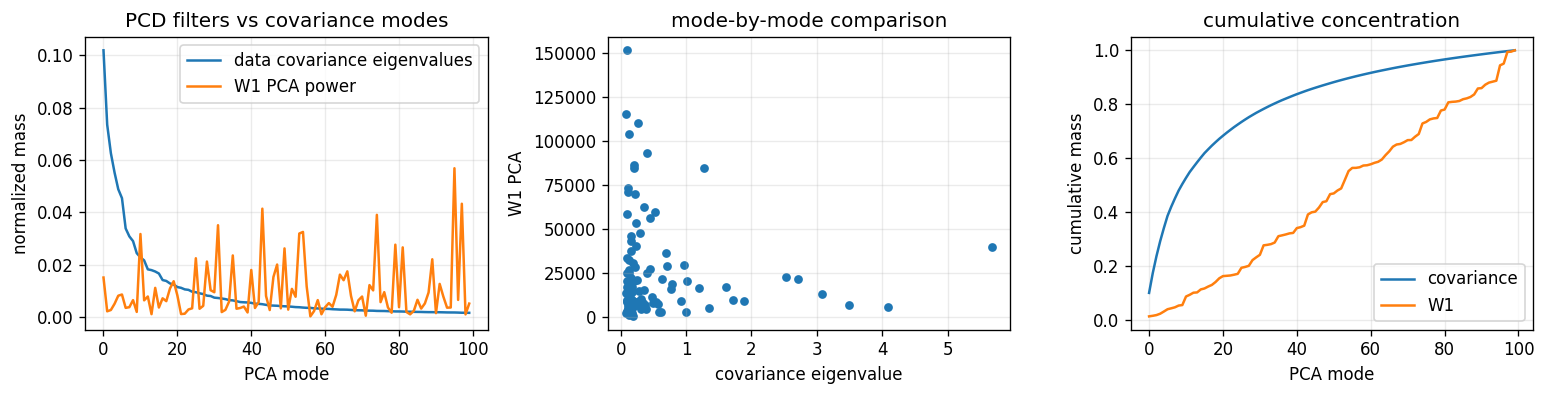

In [82]:
if dataset_filename.exists():
    projections, w1_pca_power = project_w1_on_pca(w1, pca_vecs)
    n_modes = min(100, len(pca_eigvals), len(w1_pca_power))

    eig_norm = pca_eigvals[:n_modes] / pca_eigvals[:n_modes].sum()
    power_norm = w1_pca_power[:n_modes] / w1_pca_power[:n_modes].sum()
    corr = np.corrcoef(pca_eigvals[:n_modes], w1_pca_power[:n_modes])[0, 1]
    rank_corr = np.corrcoef(
        np.argsort(np.argsort(pca_eigvals[:n_modes])),
        np.argsort(np.argsort(w1_pca_power[:n_modes])),
    )[0, 1]

    print("projection shape:", projections.shape)
    print("corr eigenvalues vs W1 PCA power:", float(corr))
    print("rank corr eigenvalues vs W1 PCA power:", float(rank_corr))

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    axes[0].plot(eig_norm, label="data covariance eigenvalues")
    axes[0].plot(power_norm, label="W1 PCA power")
    axes[0].set_xlabel("PCA mode")
    axes[0].set_ylabel("normalized mass")
    axes[0].set_title("PCD filters vs covariance modes")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].scatter(pca_eigvals[:n_modes], w1_pca_power[:n_modes], s=18)
    axes[1].set_xlabel("covariance eigenvalue")
    axes[1].set_ylabel("W1 PCA")
    axes[1].set_title("mode-by-mode comparison")
    axes[1].grid(alpha=0.25)

    axes[2].plot(np.cumsum(eig_norm), label="covariance")
    axes[2].plot(np.cumsum(power_norm), label="W1")
    axes[2].set_xlabel("PCA mode")
    axes[2].set_ylabel("cumulative mass")
    axes[2].set_title("cumulative concentration")
    axes[2].legend()
    axes[2].grid(alpha=0.25)
    fig.tight_layout()
else:
    print("dataset_filename introuvable:", dataset_filename)


## Évolution de W1 et b1 entre plusieurs updates

Charge quelques checkpoints et trace des statistiques simples de `W1` et `b1`.

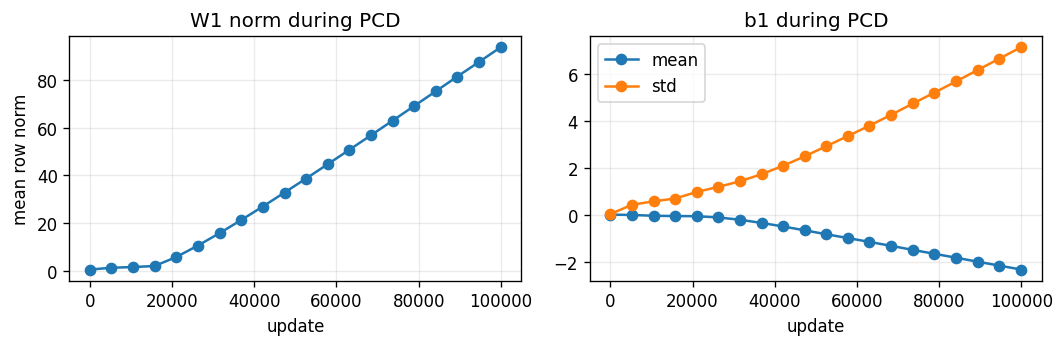

In [83]:
updates_to_compare = saved_updates[np.linspace(0, len(saved_updates) - 1, min(20, len(saved_updates))).astype(int)]
w1_norms = []
b1_means = []
b1_stds = []
for upd in updates_to_compare:
    p = load_params(str(filename), int(upd), device=device, dtype=dtype)
    w, b = get_w1_b1(p)
    w1_norms.append(np.linalg.norm(w, axis=1).mean())
    b1_means.append(b.mean())
    b1_stds.append(b.std())

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(updates_to_compare, w1_norms, marker="o")
axes[0].set_xlabel("update")
axes[0].set_ylabel("mean row norm")
axes[0].set_title("W1 norm during PCD")
axes[0].grid(alpha=0.25)

axes[1].plot(updates_to_compare, b1_means, marker="o", label="mean")
axes[1].plot(updates_to_compare, b1_stds, marker="o", label="std")
axes[1].set_xlabel("update")
axes[1].set_title("b1 during PCD")
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()